# PunePulse — Exploratory Data Analysis
**Pune Restaurant Demand Intelligence Platform**

Every chart in this notebook answers one question: **what business decision does this support?**

---

## Notebook Roadmap
| Section | Data Used | Business Output |
|---|---|---|
| 1 — Restaurant Landscape | restaurants_cleaned, resta_data | Market gaps, saturation, pricing zones |
| 2 — Demand Signals | pune_food_trends_2024 | Cuisine trends, search seasonality |
| 3 — Operational Analytics | synthetic_orders, synthetic_footfall | Rush hours, rain impact, locality patterns |
| 4 — Business Insights | All of the above | Inventory, staffing, pricing recommendations |

---
## 0. Setup & Imports

**Why this cell exists:** Before any analysis, we import every library we need and configure display settings once. Doing this at the top means every cell below can focus purely on logic.

**What each import does:**
- `pandas` — tabular data manipulation (your primary tool for this entire project)
- `numpy` — numerical operations; pandas uses it internally
- `matplotlib` — base plotting engine; seaborn and plotly build on top of it
- `seaborn` — statistical visualisation with cleaner defaults than raw matplotlib
- `plotly.express` — interactive charts; great for geographic and time-series plots
- `warnings` — we suppress non-critical warnings so the notebook output stays readable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────
# rcParams controls global matplotlib style.
# Setting these once here means every plt.plot() call below
# automatically uses these sizes and font sizes.
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# seaborn theme: 'whitegrid' adds horizontal gridlines
# which make bar chart values easier to read
sns.set_theme(style='whitegrid', palette='muted')

# pandas display: show all columns when printing a dataframe
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Output directory ──────────────────────────────────────────────────
import os
os.makedirs('../outputs/charts', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 0.1 Load All Datasets

**Why load everything upfront?** It surfaces missing files or column name mismatches immediately, before you're 10 cells deep in analysis. Each `print` statement below is a sanity check — shape, dtypes, and a `.head()` tell you whether the file loaded correctly.

In [2]:
# ── Load ──────────────────────────────────────────────────────────────
restaurants   = pd.read_csv(r'C:\Users\chari\OneDrive\Desktop\Projects\Pune Restaurant Demand Intelligence Platform\data\cleaned\restaurants_cleaned.csv')
zomato        = pd.read_csv(r'C:\Users\chari\OneDrive\Desktop\Projects\Pune Restaurant Demand Intelligence Platform\data\cleaned\resta_data.csv')
trends        = pd.read_csv(r'C:\Users\chari\OneDrive\Desktop\Projects\Pune Restaurant Demand Intelligence Platform\data\cleaned\pune_food_trends_2024.csv')
orders        = pd.read_csv(r'C:\Users\chari\OneDrive\Desktop\Projects\Pune Restaurant Demand Intelligence Platform\data\synthetic_orders.csv')
footfall      = pd.read_csv(r'C:\Users\chari\OneDrive\Desktop\Projects\Pune Restaurant Demand Intelligence Platform\data\synthetic_footfall.csv')

print('restaurants :', restaurants.shape)
print('zomato      :', zomato.shape)
print('trends      :', trends.shape)
print('orders      :', orders.shape)
print('footfall    :', footfall.shape)

restaurants : (455, 15)
zomato      : (9090, 17)
trends      : (53, 4)
orders      : (63921, 15)
footfall    : (87840, 11)


In [3]:
# ── Quick inspection of each dataset ─────────────────────────────────
# .info() is more useful than .head() for a first look:
# it shows dtypes AND non-null counts in one call,
# which immediately reveals missing value problems.

print('=== restaurants_cleaned ===')
restaurants.info()
print('\n=== resta_data (Zomato) ===')
zomato.info()

=== restaurants_cleaned ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   place_id             455 non-null    object 
 1   restaurant_name      455 non-null    object 
 2   locality             455 non-null    object 
 3   address              234 non-null    object 
 4   lat                  455 non-null    float64
 5   lon                  455 non-null    float64
 6   rating               428 non-null    float64
 7   review_count         428 non-null    float64
 8   price_range          455 non-null    object 
 9   business_tags        455 non-null    object 
 10  opening_hours        175 non-null    object 
 11  business_status      455 non-null    object 
 12  price_range_missing  455 non-null    bool   
 13  business_type        455 non-null    object 
 14  cuisine_type         455 non-null    object 
dtypes: bool(1), 

In [4]:
# ── Parse date columns ────────────────────────────────────────────────
# Pandas loads date columns as plain strings (dtype=object) by default.
# We convert them to datetime64 so we can do time-series operations:
# .dt.month, .dt.dayofweek, resample('W'), etc.
# If this throws an error, your date format may differ — check the raw
# values and adjust the format string accordingly.

trends['date']   = pd.to_datetime(trends['date'])
orders['date']   = pd.to_datetime(orders['date'])
footfall['date'] = pd.to_datetime(footfall['date'])

print('Date columns parsed successfully.')
print('Trends date range :', trends['date'].min(), '→', trends['date'].max())
print('Orders date range :', orders['date'].min(), '→', orders['date'].max())
print('Footfall date range:', footfall['date'].min(), '→', footfall['date'].max())

Date columns parsed successfully.
Trends date range : 2023-12-31 00:00:00 → 2024-12-29 00:00:00
Orders date range : 2024-01-04 00:00:00 → 2024-12-29 00:00:00
Footfall date range: 2024-01-01 00:00:00 → 2024-12-31 00:00:00


---
# SECTION 1 — Restaurant Landscape

**Business question this section answers:**
> *Where are the gaps in Pune's restaurant market? Which areas are oversaturated? Is premium pricing actually rewarded with better ratings?*

**Data used:** `restaurants_cleaned.csv` + `resta_data.csv`

### 1.1 Cuisine Distribution
**Business question:** Which cuisines dominate Pune, and which are underserved?

**Concept — value_counts():**
This is the most-used pandas method in EDA. It counts how many times each unique value appears in a column and returns a sorted Series. Think of it as a frequency table.

In [5]:
# ── Zomato has richer cuisine tags — use those ────────────────────────
# Zomato stores cuisines as comma-separated strings like
# "North Indian, Biryani, Mughlai". We split each string into
# individual tags, explode (one row per tag), then count.

# Step 1: split the string on comma, strip whitespace
cuisine_series = (
    zomato['cuisine']
    .dropna()
    .str.split(',')
)

# Step 2: explode — turns ["North Indian", "Biryani"] into two rows
cuisine_exploded = cuisine_series.explode().str.strip()

# Step 3: count and take top 15
cuisine_counts = cuisine_exploded.value_counts().head(15)

print(cuisine_counts)

cuisine
North Indian     3443
Fast Food        2763
Chinese          2704
Beverages        2488
Desserts         1735
Biryani          1452
Street Food      1268
Mughlai           913
Maharashtrian     891
Shake             828
Pizza             748
Sandwich          724
South Indian      720
Burger            569
Bakery            561
Name: count, dtype: int64


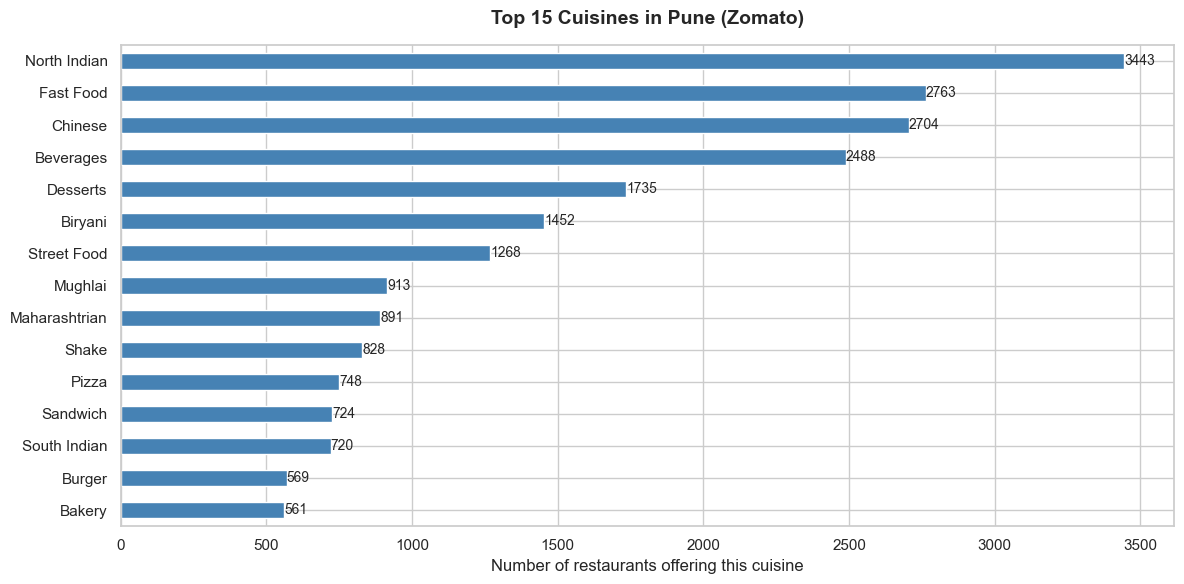


📌 Business Insight:
Top 3 cuisines represent the highest competition zones.
Cuisines outside the top 10 represent potential market gaps.


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

cuisine_counts.sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)

ax.set_title('Top 15 Cuisines in Pune (Zomato)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of restaurants offering this cuisine')
ax.set_ylabel('')

# Add value labels at end of each bar
for i, v in enumerate(cuisine_counts.sort_values()):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/1_1_cuisine_distribution.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Top 3 cuisines represent the highest competition zones.')
print('Cuisines outside the top 10 represent potential market gaps.')

### 1.2 Locality Density — Where Are Restaurants Concentrated?
**Business question:** Which areas are oversaturated? Where is there room for new entrants?

**Concept — groupby + size():**
`groupby('locality').size()` groups all rows by locality and counts how many rows are in each group. This is the foundation of almost every aggregation in pandas.

In [7]:
locality_counts = (
    restaurants
    .groupby('locality')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='restaurant_count')
)

print(locality_counts)

        locality  restaurant_count
0          Baner                59
1      Hinjewadi                59
2    Viman Nagar                59
3  Koregaon Park                58
4        Kothrud                57
5           Camp                55
6        Fc Road                55
7          Aundh                53


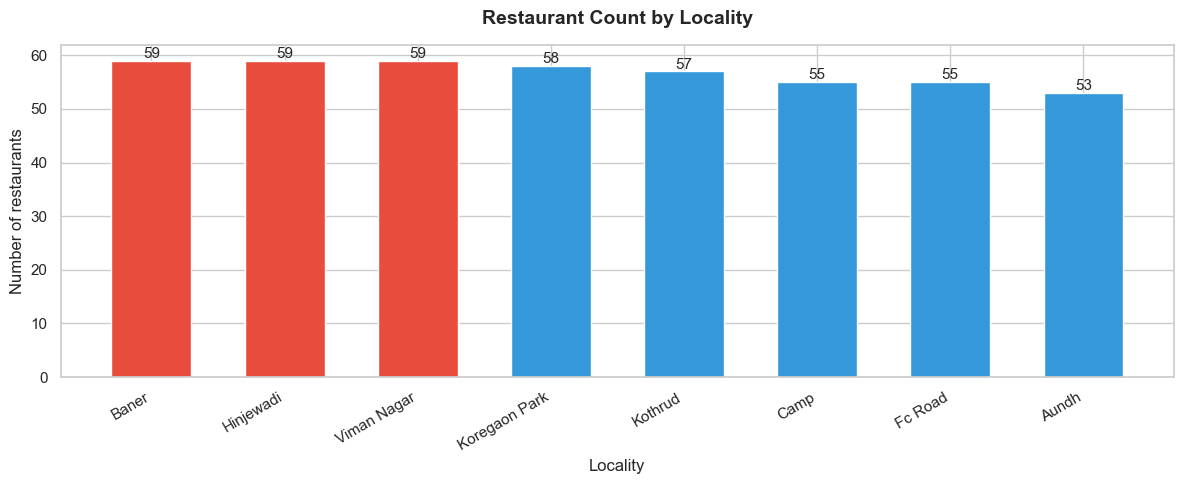


📌 Business Insight:
Red bar = most saturated locality. Entering this market requires strong differentiation.
Shorter bars = less competition, but verify demand exists before opening there.


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#e74c3c' if c == locality_counts['restaurant_count'].max()
          else '#3498db' for c in locality_counts['restaurant_count']]

bars = ax.bar(
    locality_counts['locality'],
    locality_counts['restaurant_count'],
    color=colors,
    edgecolor='white',
    width=0.6
)

ax.set_title('Restaurant Count by Locality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Locality')
ax.set_ylabel('Number of restaurants')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center', fontsize=11
    )

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/charts/1_2_locality_density.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Red bar = most saturated locality. Entering this market requires strong differentiation.')
print('Shorter bars = less competition, but verify demand exists before opening there.')

### 1.3 Premium vs Budget Areas
**Business question:** Which localities command premium pricing? Should a new restaurant in Hinjewadi price like Koregaon Park?

**Concept — groupby + agg():**
`agg()` lets you compute multiple summary statistics in one call. Here we compute mean and median cost_for_two per locality. Median is more robust than mean when there are outliers — one very expensive restaurant in a locality won't skew the median as badly as it skews the mean.

In [9]:
# ── Filter Zomato to Pune ─────────────────────────────────────────────
# Extract locality from Zomato address.
# We check which of our 8 known localities appears in the address string.

LOCALITIES = [
    'Koregaon Park', 'Baner', 'Viman Nagar', 'FC Road',
    'Kothrud', 'Hinjewadi', 'Aundh', 'Camp'
]

def extract_locality(address):
    if pd.isna(address):
        return None
    for loc in LOCALITIES:
        if loc.lower() in str(address).lower():
            return loc
    return None

zomato['locality'] = zomato['address'].apply(extract_locality)

# ── cost_for_two must be numeric ──────────────────────────────────────
# Zomato stores cost_for_two as strings like "600" or "1,200".
# We strip commas and cast to float. Errors become NaN.
zomato['cost_for_two'] = (
    zomato['cost_for_two']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)')
    [0]
    .astype(float)
)

pricing = (
    zomato
    .dropna(subset=['locality', 'cost_for_two'])
    .groupby('locality')['cost_for_two']
    .agg(['mean', 'median', 'count'])
    .round(0)
    .sort_values('median', ascending=False)
    .reset_index()
)

pricing.columns = ['locality', 'avg_cost', 'median_cost', 'n_restaurants']
print(pricing)

        locality  avg_cost  median_cost  n_restaurants
0        FC Road    489.00       400.00             60
1  Koregaon Park    653.00       400.00            137
2           Camp    393.00       300.00            168
3          Baner    396.00       300.00            458
4    Viman Nagar    391.00       300.00            356
5        Kothrud    356.00       300.00            383
6          Aundh    366.00       250.00            235
7      Hinjewadi    394.00       250.00             64


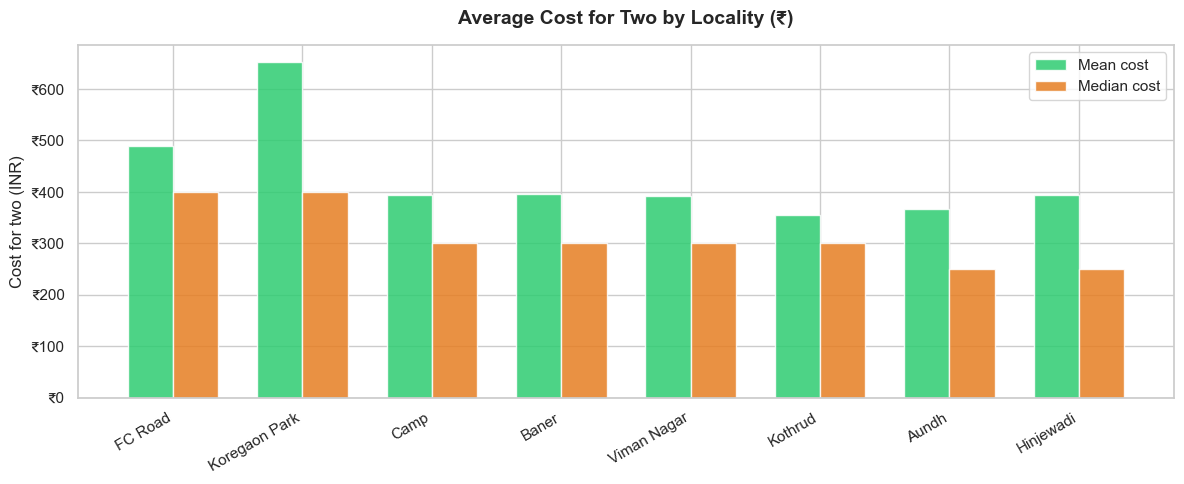


📌 Business Insight:
When mean >> median, a few expensive restaurants are pulling up the average.
Use median as the true price benchmark when entering a new locality.


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(pricing))
width = 0.35

ax.bar([i - width/2 for i in x], pricing['avg_cost'],
       width=width, label='Mean cost', color='#2ecc71', alpha=0.85)
ax.bar([i + width/2 for i in x], pricing['median_cost'],
       width=width, label='Median cost', color='#e67e22', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(pricing['locality'], rotation=30, ha='right')
ax.set_title('Average Cost for Two by Locality (₹)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Cost for two (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{int(v):,}'))
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/charts/1_3_premium_vs_budget_areas.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('When mean >> median, a few expensive restaurants are pulling up the average.')
print('Use median as the true price benchmark when entering a new locality.')

### 1.4 Ratings by Cuisine
**Business question:** Do certain cuisines consistently get higher ratings? Is quality perception cuisine-dependent?

**Concept — boxplot:**
A boxplot shows the full distribution of a variable, not just the mean. The box spans the 25th–75th percentile (the "middle 50%" of ratings). The line inside is the median. Dots outside the whiskers are outliers. This tells you far more than a bar chart of averages.

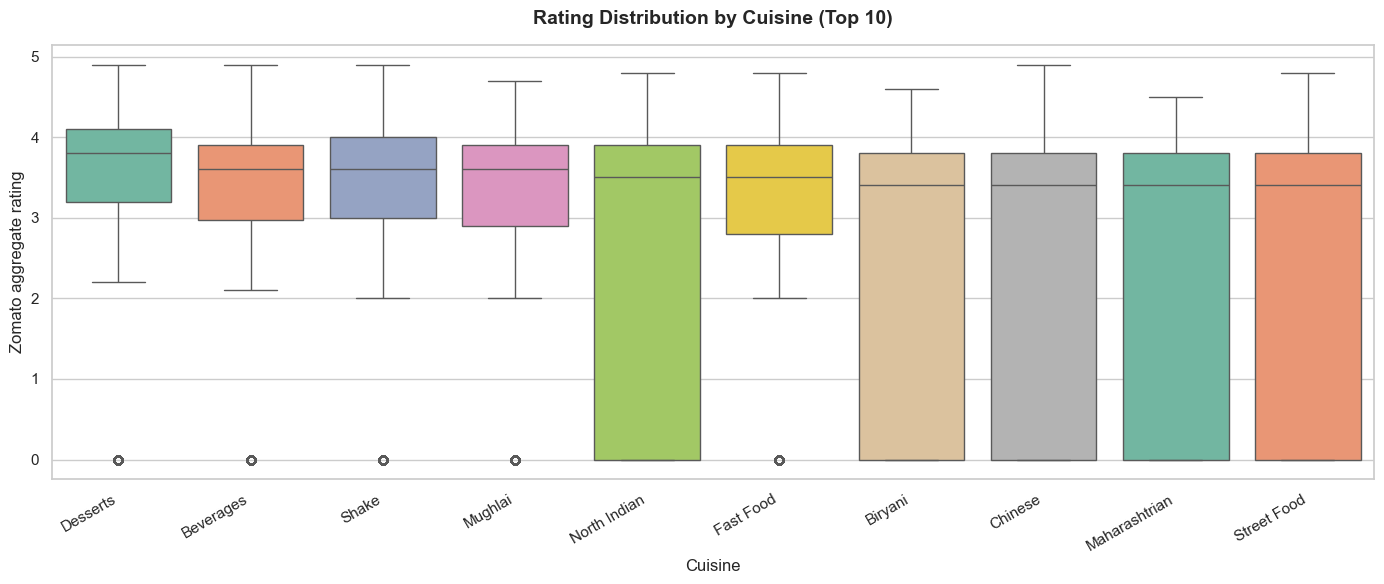


📌 Business Insight:
Cuisines with tight boxes = consistent quality expectations from customers.
Wide boxes = high variance; some restaurants excel while others disappoint.
Entering a high-median cuisine is harder — customer bar is already set high.


In [11]:
# Explode cuisines again, merge back rating
zomato['aggregate_rating'] = pd.to_numeric(zomato['aggregate_rating'], errors='coerce')

cuisine_rating = (
    zomato[['cuisine', 'aggregate_rating']]
    .dropna()
    .assign(cuisine=lambda df: df['cuisine'].str.split(','))
    .explode('cuisine')
)
cuisine_rating['cuisine'] = cuisine_rating['cuisine'].str.strip()

# Keep only top 10 cuisines by count for a readable chart
top_cuisines = cuisine_rating['cuisine'].value_counts().head(10).index
cuisine_rating_top = cuisine_rating[cuisine_rating['cuisine'].isin(top_cuisines)]

# Sort by median rating for clean visual ordering
order = (
    cuisine_rating_top
    .groupby('cuisine')['aggregate_rating']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=cuisine_rating_top,
    x='cuisine',
    y='aggregate_rating',
    order=order,
    palette='Set2',
    ax=ax
)

ax.set_title('Rating Distribution by Cuisine (Top 10)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cuisine')
ax.set_ylabel('Zomato aggregate rating')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/charts/1_4_ratings_by_cuisine.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Cuisines with tight boxes = consistent quality expectations from customers.')
print('Wide boxes = high variance; some restaurants excel while others disappoint.')
print('Entering a high-median cuisine is harder — customer bar is already set high.')

### 1.5 Restaurant Saturation — Cuisine × Locality Heatmap
**Business question:** Which cuisine-locality combinations are already crowded? Where is a specific cuisine underrepresented?

**Concept — pivot_table:**
A pivot table reshapes data from long format (one row per restaurant) to wide format (localities as rows, cuisines as columns, count as values). Think of it as Excel's pivot table, but in Python.

In [12]:
# Build cuisine × locality matrix
zomato_with_loc = zomato.dropna(subset=['locality'])

# Explode cuisines to one row per cuisine tag
exploded = (
    zomato_with_loc[['locality', 'cuisine']]
    .dropna()
    .assign(cuisine=lambda df: df['cuisine'].str.split(','))
    .explode('cuisine')
)
exploded['cuisine'] = exploded['cuisine'].str.strip()

# Keep top 10 cuisines only (chart stays readable)
top10 = exploded['cuisine'].value_counts().head(10).index
exploded = exploded[exploded['cuisine'].isin(top10)]

# pivot_table: rows=locality, cols=cuisine, values=count
# aggfunc='size' counts occurrences (same as groupby+size)
# fill_value=0 means empty cells become 0 instead of NaN
pivot = exploded.pivot_table(
    index='locality',
    columns='cuisine',
    aggfunc='size',
    fill_value=0
)

print(pivot)

cuisine        Beverages  Biryani  Chinese  Desserts  Fast Food  \
locality                                                          
Aundh                 65       42       42        60         72   
Baner                131       87      142       103        133   
Camp                  50       27       64        41         49   
FC Road               44        3       11        22         43   
Hinjewadi             10       20       27        13         12   
Koregaon Park         50       13       23        42         44   
Kothrud              127       42       84        86        125   
Viman Nagar          128       53       93        90        125   

cuisine        Maharashtrian  Mughlai  North Indian  Shake  Street Food  
locality                                                                 
Aundh                     13       24            90     16           30  
Baner                     39       61           189     36           48  
Camp                      11     

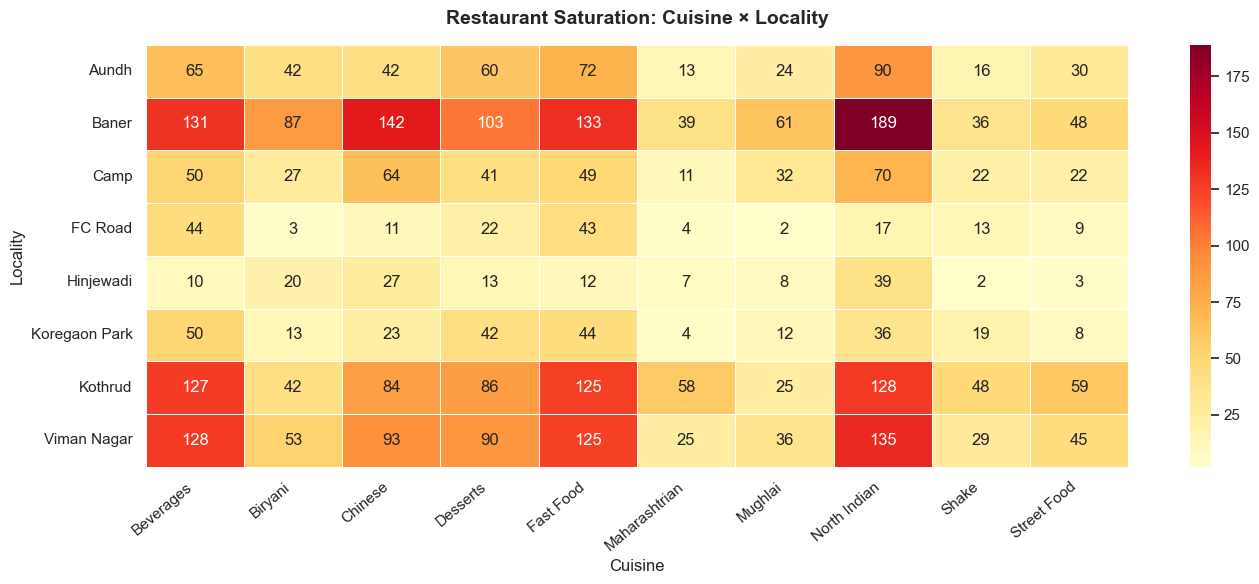


📌 Business Insight:
Dark red cells = oversaturated. Opening another restaurant of that type there is high-risk.
White/yellow cells = underserved. Could be a market gap — or low demand. Cross-check with trends data.


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    pivot,
    annot=True,          # show numbers inside each cell
    fmt='d',             # integer format
    cmap='YlOrRd',       # yellow=low, red=high
    linewidths=0.5,
    ax=ax
)

ax.set_title('Restaurant Saturation: Cuisine × Locality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cuisine')
ax.set_ylabel('Locality')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')

plt.tight_layout()
plt.savefig('../outputs/charts/1_5_saturation_heatmap.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Dark red cells = oversaturated. Opening another restaurant of that type there is high-risk.')
print('White/yellow cells = underserved. Could be a market gap — or low demand. Cross-check with trends data.')

---
# SECTION 2 — Demand Signals

**Business question this section answers:**
> *What are Pune consumers actually searching for, and how does that change across the year? Are certain cuisines trending up or fading?*

**Data used:** `pune_food_trends_2024.csv`

Google Trends data is normalised to 0–100 (100 = peak search interest for that term). It is not absolute search volume — it is *relative* interest. Use it to detect seasonality and spikes, not to compare cuisines against each other in absolute terms.

In [14]:
# ── Inspect trends data ───────────────────────────────────────────────
print(trends.head(10))
print('\nColumns:', trends.columns.tolist())
print('Shape:', trends.shape)

        date  biryani Pune  cafe Pune  misal pav
0 2023-12-31            24         83         41
1 2024-01-07            22         78         33
2 2024-01-14            18         79         36
3 2024-01-21            23         78         34
4 2024-01-28            20         75         34
5 2024-02-04            20         75         24
6 2024-02-11            18         81         33
7 2024-02-18            18         70         32
8 2024-02-25            18         80         33
9 2024-03-03            18         78         30

Columns: ['date', 'biryani Pune', 'cafe Pune', 'misal pav']
Shape: (53, 4)


### 2.1 Full-Year Search Interest Trends
**Business question:** When do customers start searching more for specific food types? Are there predictable seasonal peaks?

**Concept — time-series line plot:**
Setting the date column as the x-axis and plotting multiple columns gives you a multi-line chart. Each line is one cuisine's search interest over time.

Trend columns found: ['biryani Pune', 'cafe Pune', 'misal pav']


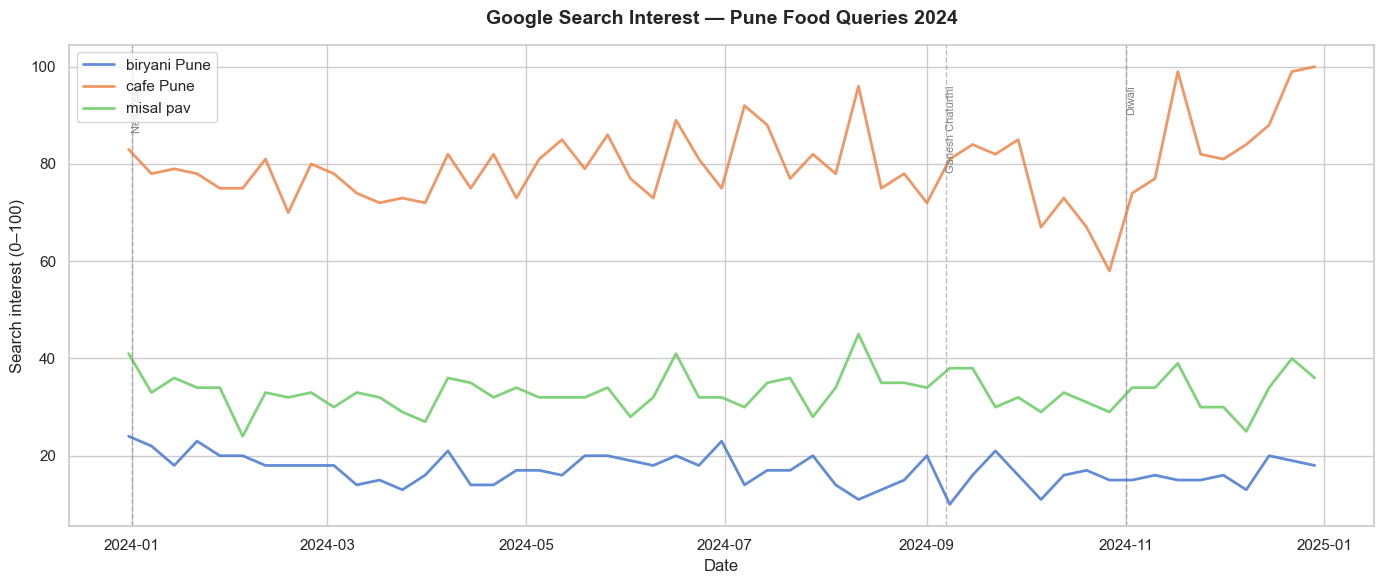


📌 Business Insight:
Spikes near festival lines = search interest driven by festivals.
Sustained rises = organic cuisine trend growth (not festival-driven).


In [15]:
# Identify the cuisine/query columns (everything except 'date')
trend_cols = [c for c in trends.columns if c != 'date']
print('Trend columns found:', trend_cols)

fig, ax = plt.subplots(figsize=(14, 6))

for col in trend_cols:
    ax.plot(
        trends['date'],
        trends[col],
        label=col,
        linewidth=2,
        alpha=0.85
    )

# Mark Pune-specific festival dates
festivals = {
    'Ganesh Chaturthi': '2024-09-07',
    'Diwali': '2024-11-01',
    'New Year': '2024-01-01'
}

for name, date in festivals.items():
    ax.axvline(
        pd.Timestamp(date),
        color='gray', linestyle='--', alpha=0.5, linewidth=1
    )
    ax.text(
        pd.Timestamp(date), ax.get_ylim()[1] * 0.92,
        name, fontsize=8, color='gray', rotation=90, va='top'
    )

ax.set_title('Google Search Interest — Pune Food Queries 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Search interest (0–100)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/charts/2_1_search_trends_fullyr.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Spikes near festival lines = search interest driven by festivals.')
print('Sustained rises = organic cuisine trend growth (not festival-driven).')

### 2.2 Weekly Search Behaviour — Average by Day of Week
**Business question:** Do people search for food more on Fridays and Saturdays? When should restaurants increase promotions?

**Concept — .dt accessor:**
Once a column is datetime type, `.dt.day_name()` extracts the weekday name. This is one of many `.dt` properties: `.dt.month`, `.dt.quarter`, `.dt.hour`, `.dt.is_month_end`, etc.

In [16]:
trends['day_of_week'] = trends['date'].dt.day_name()

# Order days correctly (Mon–Sun)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly = (
    trends
    .groupby('day_of_week')[trend_cols]
    .mean()
    .reindex(day_order)       # reindex enforces correct day order
    .round(1)
)

print(weekly)

             biryani Pune  cafe Pune  misal pav
day_of_week                                    
Monday                NaN        NaN        NaN
Tuesday               NaN        NaN        NaN
Wednesday             NaN        NaN        NaN
Thursday              NaN        NaN        NaN
Friday                NaN        NaN        NaN
Saturday              NaN        NaN        NaN
Sunday              17.10      79.70      33.20


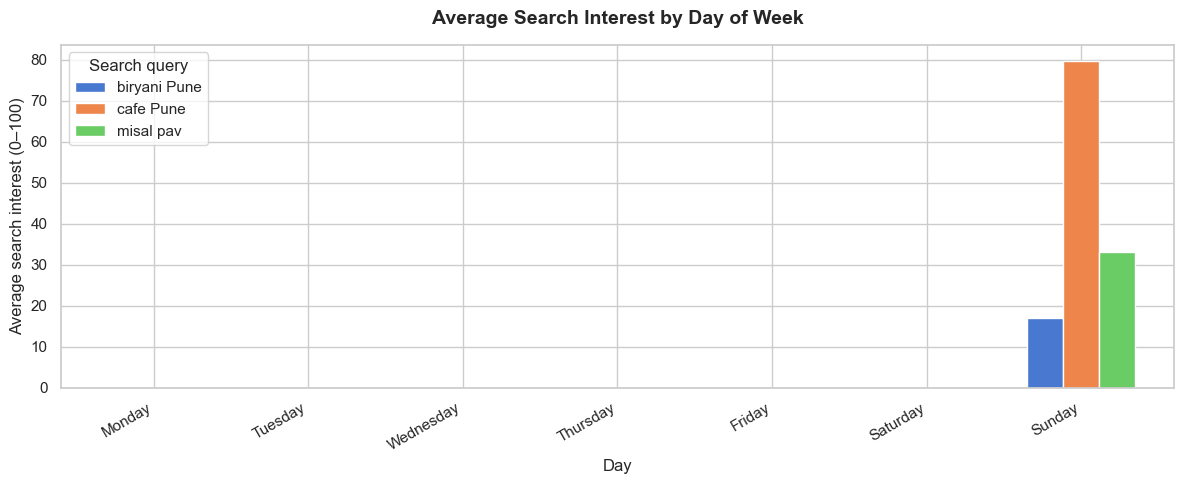


📌 Business Insight:
If Friday/Saturday searches are 15%+ higher, that is a signal to run weekend-specific promotions.
Low midweek interest → midweek discount campaigns may help fill capacity.


In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

weekly.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')

ax.set_title('Average Search Interest by Day of Week', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day')
ax.set_ylabel('Average search interest (0–100)')
ax.set_xticklabels(day_order, rotation=30, ha='right')
ax.legend(title='Search query')

plt.tight_layout()
plt.savefig('../outputs/charts/2_2_weekly_search_behaviour.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('If Friday/Saturday searches are 15%+ higher, that is a signal to run weekend-specific promotions.')
print('Low midweek interest → midweek discount campaigns may help fill capacity.')

### 2.3 Rolling Average — Smoothing Out Noise
**Business question:** What is the true underlying trend once we remove week-to-week noise?

**Concept — rolling():**
A 4-week rolling average replaces each data point with the average of itself and the 3 weeks before it. This smooths out random spikes (a holiday, an outlier week) and reveals the underlying trend direction. `min_periods=1` means we don't lose the first few rows while the window fills up.

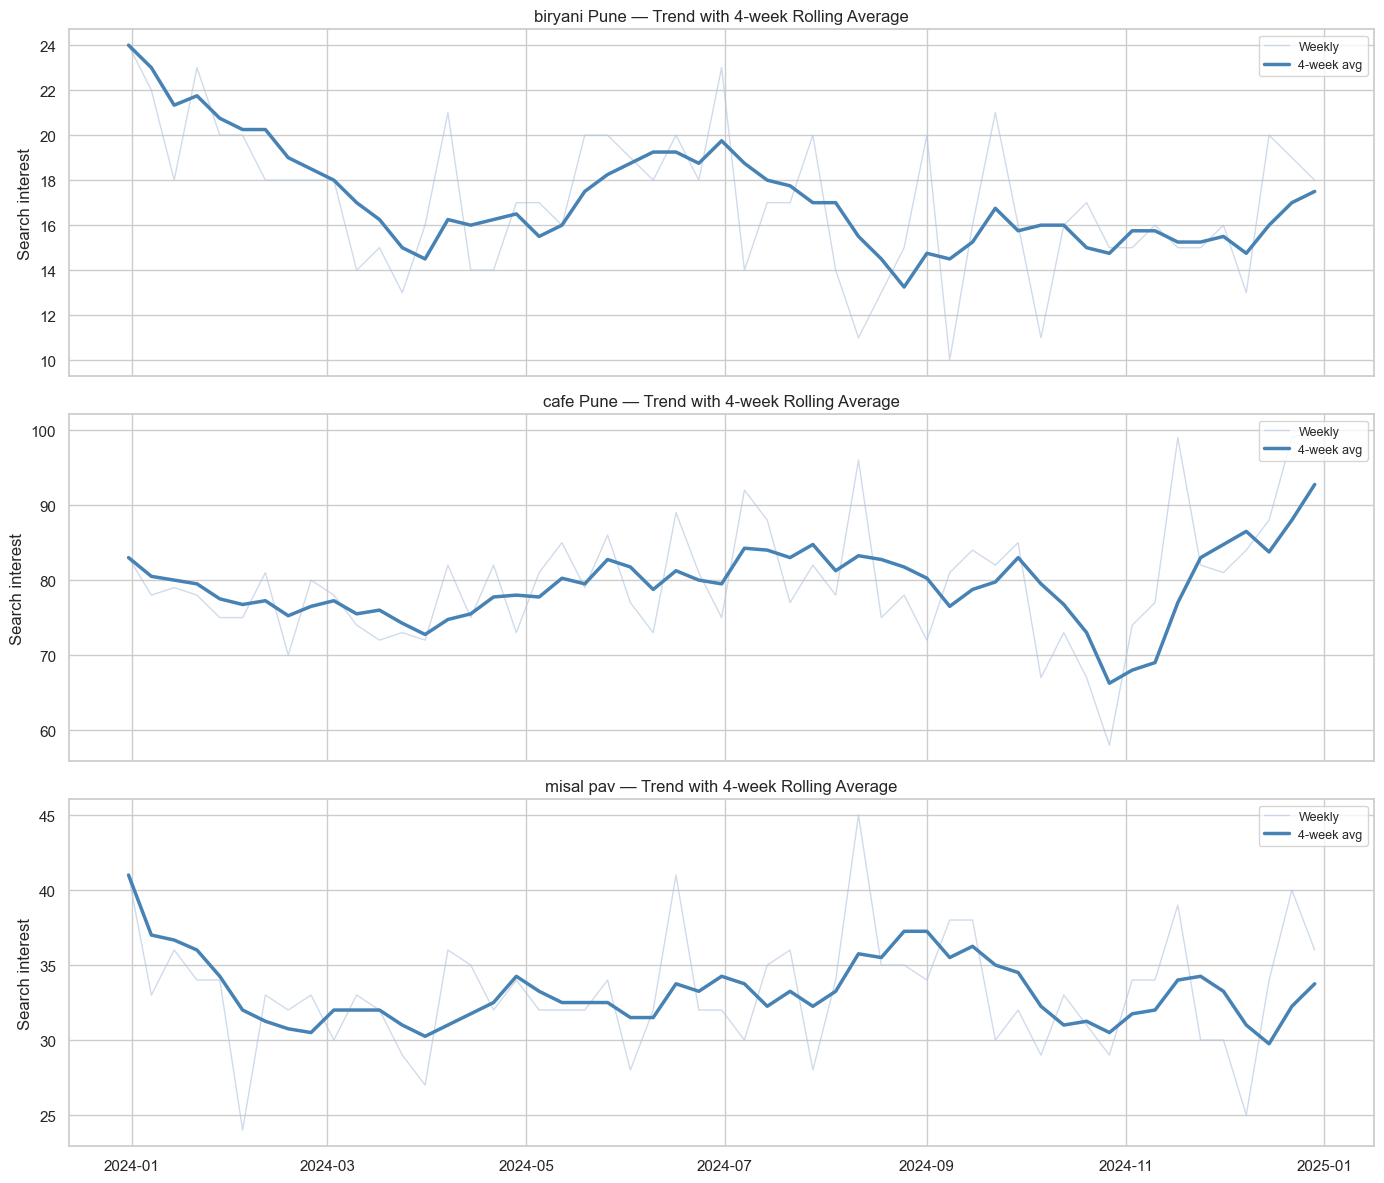


📌 Business Insight:
Rising rolling average = sustained demand growth. Not just a one-week spike.
Falling rolling average heading into a season = pre-emptively reduce inventory.


In [18]:
trends_sorted = trends.sort_values('date').set_index('date')

fig, axes = plt.subplots(
    len(trend_cols), 1,
    figsize=(14, 4 * len(trend_cols)),
    sharex=True
)

# If only one trend column, axes won't be a list — normalise it
if len(trend_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, trend_cols):

    # Raw weekly data
    ax.plot(
        trends_sorted.index,
        trends_sorted[col],
        color='lightsteelblue', alpha=0.6, linewidth=1, label='Weekly'
    )

    # 4-week rolling average
    rolling = trends_sorted[col].rolling(window=4, min_periods=1).mean()
    ax.plot(
        trends_sorted.index,
        rolling,
        color='steelblue', linewidth=2.5, label='4-week avg'
    )

    ax.set_title(f'{col} — Trend with 4-week Rolling Average', fontsize=12)
    ax.set_ylabel('Search interest')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/charts/2_3_rolling_trends.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Rising rolling average = sustained demand growth. Not just a one-week spike.')
print('Falling rolling average heading into a season = pre-emptively reduce inventory.')

---
# SECTION 3 — Operational Analytics

**Business question this section answers:**
> *When exactly do customers come? How does rain affect footfall? Which localities drive the most orders on weekends?*

**Data used:** `synthetic_orders.csv`, `synthetic_footfall.csv`

In [19]:
print('Orders columns :', orders.columns.tolist())
print('Footfall columns:', footfall.columns.tolist())

Orders columns : ['order_id', 'restaurant_name', 'locality', 'cuisine', 'date', 'hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'festival', 'primary_dish', 'n_items', 'order_value_inr', 'group_size', 'price_range']
Footfall columns: ['restaurant_name', 'locality', 'cuisine', 'date', 'hour', 'footfall', 'is_weekend', 'month', 'is_monsoon', 'festival', 'day_of_week']


### 3.1 Hourly Footfall — The Rush Hour Profile
**Business question:** When do customers actually arrive? Where should staffing be highest?

**Concept — groupby + mean on a numeric column:**
We group by `hour` and compute the mean footfall across all restaurants and days. This gives the average footfall profile across a full day.

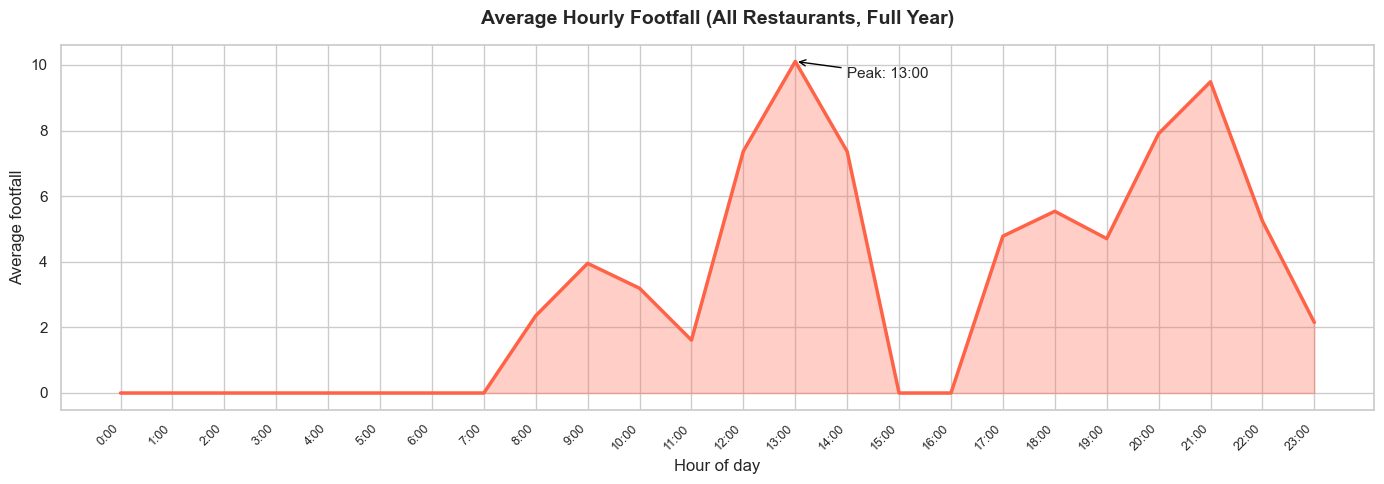


📌 Business Insight:
Peak footfall at 13:00.
Restaurants should have maximum staff 1 hour before peak to handle prep.
Hours with near-zero footfall are candidates for kitchen deep-cleaning or inventory restocking.


In [20]:
hourly_avg = (
    footfall
    .groupby('hour')['footfall']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    hourly_avg['hour'],
    hourly_avg['footfall'],
    alpha=0.3, color='tomato'
)
ax.plot(
    hourly_avg['hour'],
    hourly_avg['footfall'],
    color='tomato', linewidth=2.5
)

# Mark peak hours
peak_hour = hourly_avg.loc[hourly_avg['footfall'].idxmax(), 'hour']
peak_val  = hourly_avg['footfall'].max()
ax.annotate(
    f'Peak: {int(peak_hour)}:00',
    xy=(peak_hour, peak_val),
    xytext=(peak_hour + 1, peak_val * 0.95),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=11
)

ax.set_title('Average Hourly Footfall (All Restaurants, Full Year)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average footfall')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/charts/3_1_hourly_footfall.png', dpi=150)
plt.show()

print(f'\n📌 Business Insight:')
print(f'Peak footfall at {int(peak_hour)}:00.')
print('Restaurants should have maximum staff 1 hour before peak to handle prep.')
print('Hours with near-zero footfall are candidates for kitchen deep-cleaning or inventory restocking.')

### 3.2 Weekend vs Weekday Demand
**Business question:** How much more demand should restaurants expect on weekends? Is it worth hiring weekend-only staff?

**Concept — boolean groupby:**
`is_weekend` is a 0/1 column. Grouping on it splits all rows into two groups. We compare average footfall and order value between the two groups.

In [21]:
weekend_footfall = (
    footfall
    .groupby('is_weekend')['footfall']
    .agg(['mean', 'median', 'sum'])
    .round(1)
)
weekend_footfall.index = ['Weekday', 'Weekend']
print('Footfall — Weekday vs Weekend:')
print(weekend_footfall)

weekend_orders = (
    orders
    .groupby('is_weekend')['order_value_inr']
    .agg(['mean', 'count'])
    .round(1)
)
weekend_orders.index = ['Weekday', 'Weekend']
print('\nOrders — Weekday vs Weekend:')
print(weekend_orders)

Footfall — Weekday vs Weekend:
         mean  median     sum
Weekday  2.90    1.00  182076
Weekend  3.80    2.00   95176

Orders — Weekday vs Weekend:
          mean  count
Weekday 180.50  41947
Weekend 179.70  21974


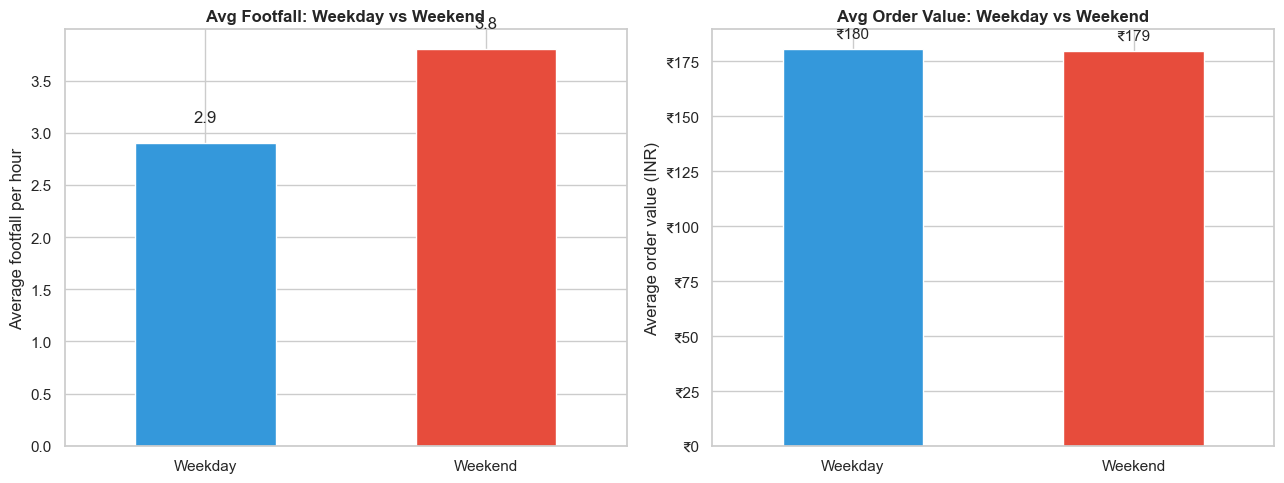


📌 Business Insight:
Weekend footfall is 31.0% higher than weekday average.
If uplift > 20%, hiring weekend-only part-time staff is likely cost-positive.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Footfall comparison
weekend_footfall['mean'].plot(
    kind='bar', ax=axes[0],
    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5
)
axes[0].set_title('Avg Footfall: Weekday vs Weekend', fontweight='bold')
axes[0].set_ylabel('Average footfall per hour')
axes[0].set_xticklabels(['Weekday', 'Weekend'], rotation=0)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}',
        ha='center', fontsize=12
    )

# Chart 2: Average order value
weekend_orders['mean'].plot(
    kind='bar', ax=axes[1],
    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5
)
axes[1].set_title('Avg Order Value: Weekday vs Weekend', fontweight='bold')
axes[1].set_ylabel('Average order value (INR)')
axes[1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{int(v):,}'))

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'₹{int(bar.get_height()):,}',
        ha='center', fontsize=11
    )

plt.tight_layout()
plt.savefig('../outputs/charts/3_2_weekend_vs_weekday.png', dpi=150)
plt.show()

# Calculate and print the uplift %
uplift = (weekend_footfall.loc['Weekend','mean'] / weekend_footfall.loc['Weekday','mean'] - 1) * 100
print(f'\n📌 Business Insight:')
print(f'Weekend footfall is {uplift:.1f}% higher than weekday average.')
print('If uplift > 20%, hiring weekend-only part-time staff is likely cost-positive.')

### 3.3 Monsoon Impact on Footfall
**Business question:** How badly does the monsoon hurt dine-in traffic? By how much should inventory be reduced in June–September?

**Concept — conditional groupby:**
The `is_monsoon` flag in your data marks June–September. Comparing monsoon vs non-monsoon footfall quantifies the impact cleanly.

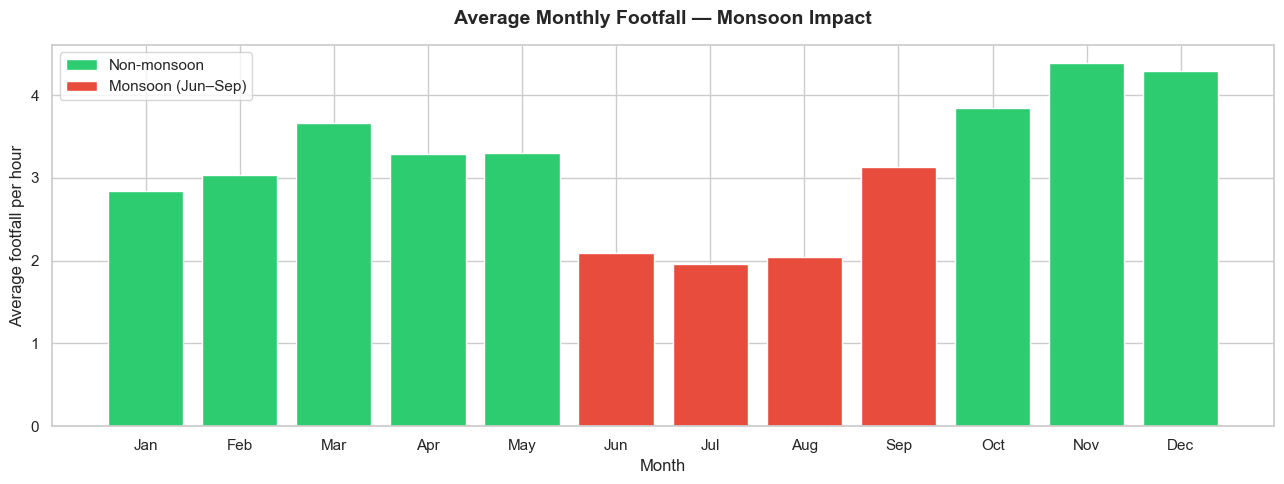


📌 Business Insight:
Monsoon months average 2.3 footfall vs 3.6 non-monsoon.
That is a 35.7% dip in dine-in traffic.
Perishable inventory (vegetables, dairy) should be reduced by ~36% Jun–Sep.
Delivery orders may offset some dine-in loss — check delivery_rating in Zomato data.


In [23]:
footfall['month'] = footfall['date'].dt.month

monthly_avg = (
    footfall
    .groupby('month')['footfall']
    .mean()
    .reset_index()
)

# Label monsoon months (June=6 to September=9)
monthly_avg['is_monsoon'] = monthly_avg['month'].between(6, 9)

month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}
monthly_avg['month_name'] = monthly_avg['month'].map(month_names)

fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#e74c3c' if m else '#2ecc71' for m in monthly_avg['is_monsoon']]

bars = ax.bar(
    monthly_avg['month_name'],
    monthly_avg['footfall'],
    color=colors,
    edgecolor='white'
)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Non-monsoon'),
    Patch(facecolor='#e74c3c', label='Monsoon (Jun–Sep)')
]
ax.legend(handles=legend_elements)

ax.set_title('Average Monthly Footfall — Monsoon Impact', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Average footfall per hour')

plt.tight_layout()
plt.savefig('../outputs/charts/3_3_monsoon_impact.png', dpi=150)
plt.show()

# Quantify the monsoon dip
monsoon_avg     = footfall[footfall['is_monsoon'] == 1]['footfall'].mean()
non_monsoon_avg = footfall[footfall['is_monsoon'] == 0]['footfall'].mean()
dip = (1 - monsoon_avg / non_monsoon_avg) * 100

print(f'\n📌 Business Insight:')
print(f'Monsoon months average {monsoon_avg:.1f} footfall vs {non_monsoon_avg:.1f} non-monsoon.')
print(f'That is a {dip:.1f}% dip in dine-in traffic.')
print(f'Perishable inventory (vegetables, dairy) should be reduced by ~{dip:.0f}% Jun–Sep.')
print('Delivery orders may offset some dine-in loss — check delivery_rating in Zomato data.')

### 3.4 Festival Demand Spikes
**Business question:** How much extra demand do specific festivals create? What is the advance warning time to stock up?

**Concept — groupby on a categorical column:**
`festival` is a string column with values like `"Ganesh Chaturthi"`, `"Diwali"`, `"None"`. Grouping on it lets us directly compare festival vs non-festival footfall.

⚠️ No 'None' festival rows found. Using overall mean as baseline.
           festival  mean  count  uplift_pct
0            Diwali  7.80    480       42.30
1      New Year Eve  7.00    240       27.70
2  Ganesh Chaturthi  4.90    720      -10.60
3        Gudi Padwa  4.60    240      -16.10
4              none  3.10  86160      -43.40


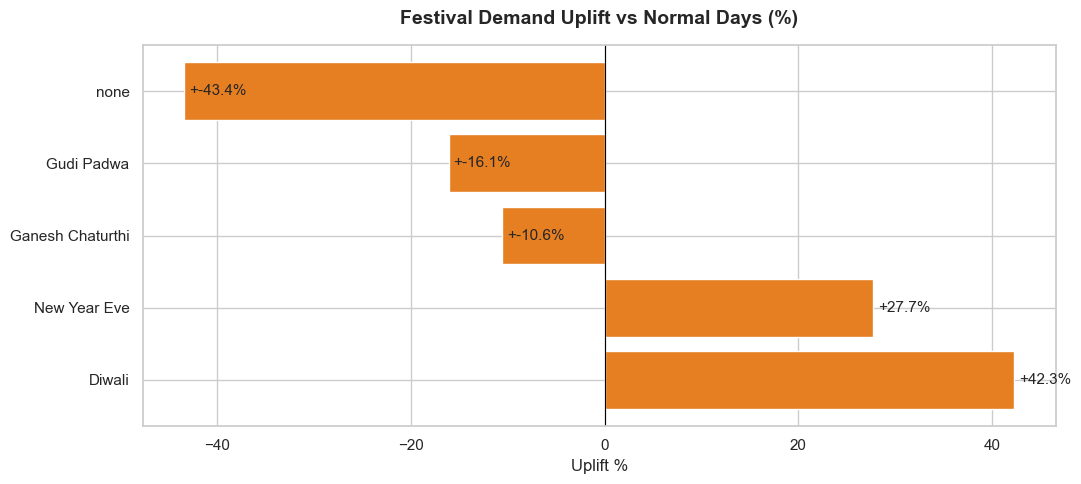


📌 Business Insight:
Diwali: +42.3% footfall uplift.
New Year Eve: +27.7% footfall uplift.
Ganesh Chaturthi: +-10.6% footfall uplift.
Gudi Padwa: +-16.1% footfall uplift.
none: +-43.4% footfall uplift.

Stock up on high-turnover ingredients 2–3 days before each festival.
This is a direct input to your Inventory Guidance dashboard module.


In [24]:
festival_avg = (
    footfall
    .groupby('festival')['footfall']
    .agg(['mean', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
    .reset_index()
)

baseline = festival_avg.loc[festival_avg['festival'] == 'None', 'mean'].values

if len(baseline) > 0:
    baseline = baseline[0]
    festival_avg['uplift_pct'] = ((festival_avg['mean'] / baseline) - 1) * 100
    festival_avg['uplift_pct'] = festival_avg['uplift_pct'].round(1)
else:
    baseline = festival_avg['mean'].mean()
    festival_avg['uplift_pct'] = ((festival_avg['mean'] / baseline) - 1) * 100
    festival_avg['uplift_pct'] = festival_avg['uplift_pct'].round(1)
    print("⚠️ No 'None' festival rows found. Using overall mean as baseline.")

print(festival_avg)

# Plot only the festival rows (exclude 'None')
festival_plot = festival_avg[festival_avg['festival'] != 'None'].copy()

if not festival_plot.empty:
    fig, ax = plt.subplots(figsize=(11, 5))

    bars = ax.barh(
        festival_plot['festival'],
        festival_plot['uplift_pct'],
        color='#e67e22',
        edgecolor='white'
    )

    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Festival Demand Uplift vs Normal Days (%)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Uplift %')

    for bar in bars:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'+{bar.get_width():.1f}%',
            va='center', fontsize=11
        )

    plt.tight_layout()
    plt.savefig('../outputs/charts/3_4_festival_spikes.png', dpi=150)
    plt.show()

    print('\n📌 Business Insight:')
    for _, row in festival_plot.iterrows():
        print(f'{row["festival"]}: +{row["uplift_pct"]:.1f}% footfall uplift.')
    print('\nStock up on high-turnover ingredients 2–3 days before each festival.')
    print('This is a direct input to your Inventory Guidance dashboard module.')

### 3.5 Locality Demand Patterns
**Business question:** Does footfall peak at the same hour everywhere? Or do Hinjewadi (IT crowd) and Kothrud (residential) behave differently?

**Concept — groupby with multiple keys:**
`groupby(['locality', 'hour'])` creates a group for every unique combination of locality and hour — so you get the average footfall at 9pm in Baner, 9pm in Kothrud, etc.

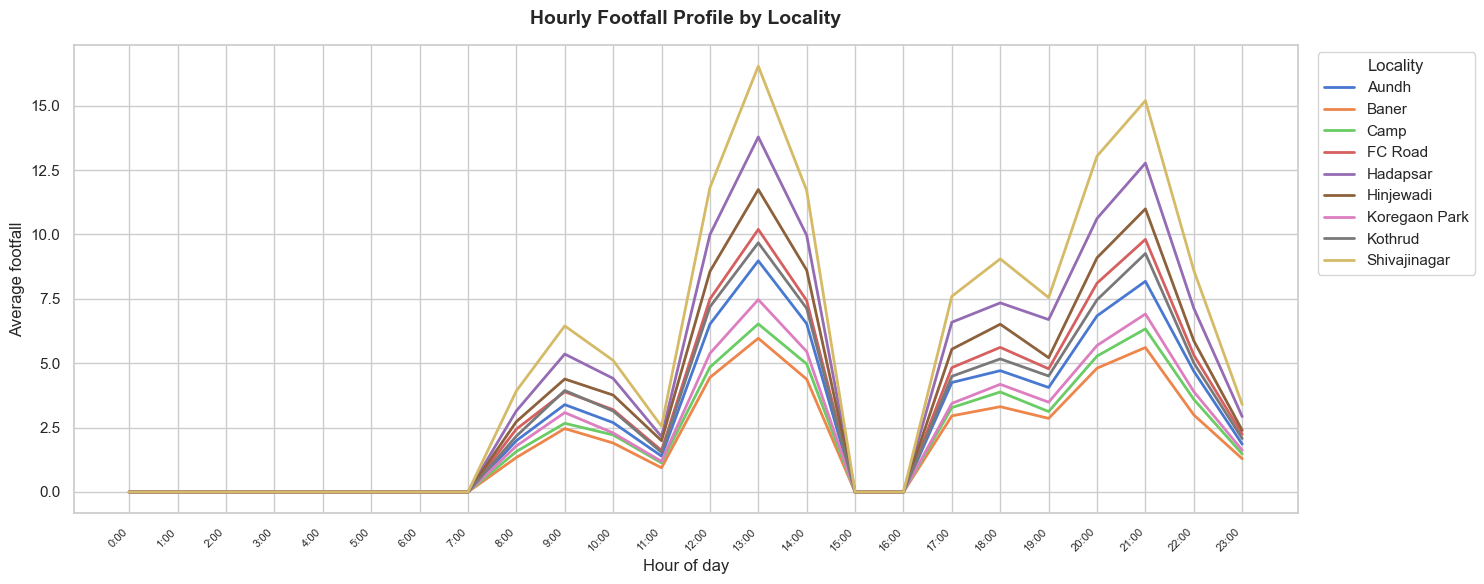


📌 Business Insight:
Lines that peak earlier = lunch-dominant areas (often IT parks like Hinjewadi).
Lines that peak later = dinner-dominant areas (residential like Kothrud).
Stagger staff shift timings per locality rather than using a one-size-fits-all schedule.


In [25]:
locality_hour = (
    footfall
    .groupby(['locality', 'hour'])['footfall']
    .mean()
    .reset_index()
)

# pivot to wide format: rows=hour, cols=locality
locality_pivot = locality_hour.pivot(index='hour', columns='locality', values='footfall')

fig, ax = plt.subplots(figsize=(15, 6))

for col in locality_pivot.columns:
    ax.plot(locality_pivot.index, locality_pivot[col], label=col, linewidth=2)

ax.set_title('Hourly Footfall Profile by Locality', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average footfall')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.legend(title='Locality', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/charts/3_5_locality_hourly_demand.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Business Insight:')
print('Lines that peak earlier = lunch-dominant areas (often IT parks like Hinjewadi).')
print('Lines that peak later = dinner-dominant areas (residential like Kothrud).')
print('Stagger staff shift timings per locality rather than using a one-size-fits-all schedule.')

### 3.6 Order Value Distribution by Cuisine
**Business question:** Which cuisines drive higher revenue per order? Where should restaurants invest in upselling?

**Concept — violin plot:**
A violin plot combines a boxplot with a kernel density estimate (KDE). The width at each value shows how many data points fall there. Wider = more orders at that price. Better than a bar chart because you see the full distribution shape.

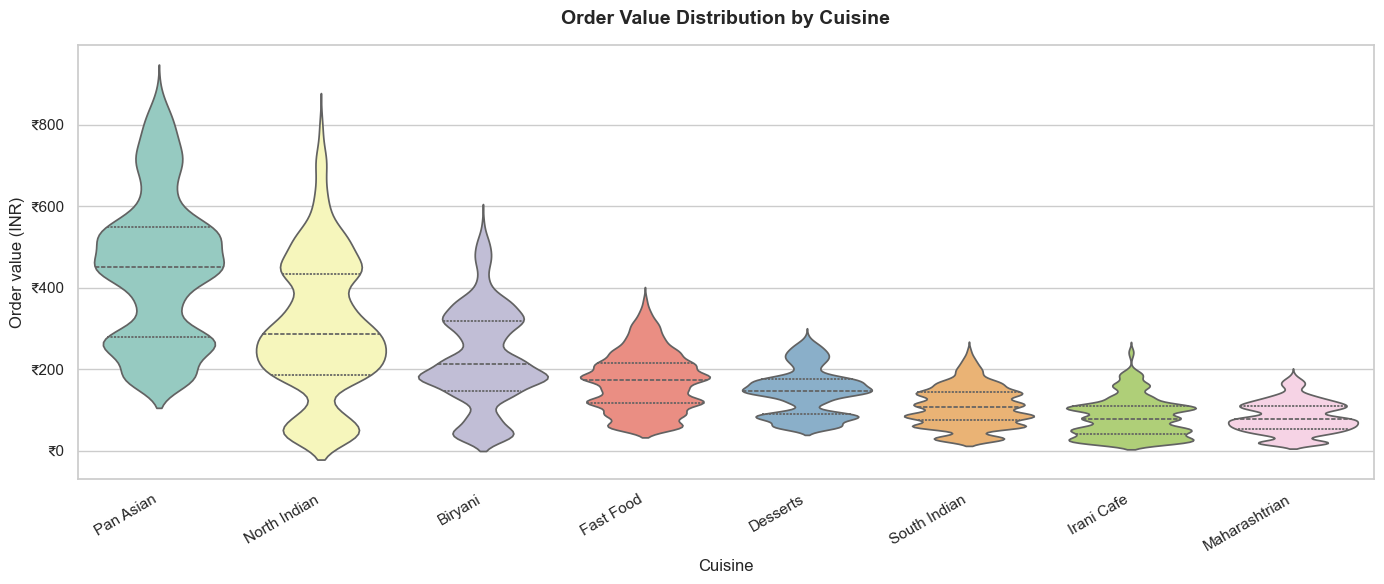


📌 Business Insight:
Wide violin body at high INR = many customers spending that amount.
Cuisines with high medians but narrow violins = consistent premium spenders.
Target upselling (desserts, drinks) at tables ordering from high-median cuisines.


In [26]:
# Keep top 8 cuisines by order count
top_cuisines_orders = orders['cuisine'].value_counts().head(8).index
orders_top = orders[orders['cuisine'].isin(top_cuisines_orders)]

# Sort by median order value
cuisine_order = (
    orders_top
    .groupby('cuisine')['order_value_inr']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=orders_top,
    x='cuisine',
    y='order_value_inr',
    order=cuisine_order,
    palette='Set3',
    inner='quartile',   # show quartile lines inside violin
    ax=ax
)

ax.set_title('Order Value Distribution by Cuisine', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cuisine')
ax.set_ylabel('Order value (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{int(v):,}'))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/charts/3_6_order_value_by_cuisine.png', dpi=150)
plt.show()

print('\n📌 Business Insight:')
print('Wide violin body at high INR = many customers spending that amount.')
print('Cuisines with high medians but narrow violins = consistent premium spenders.')
print('Target upselling (desserts, drinks) at tables ordering from high-median cuisines.')

---
# SECTION 4 — Business Insights

This section converts the charts above into **concrete, actionable recommendations**. Each insight follows the same structure:
- **What the data shows** (one number or comparison)
- **What a restaurant owner should do** (the decision it supports)
- **When to act** (timing)

These become the text cards in your dashboard's Operational Alerts and Inventory Guidance modules.

In [27]:
# ── Compute all insight values in one cell ────────────────────────────

# 1. Weekend footfall uplift
wkend = footfall[footfall['is_weekend'] == 1]['footfall'].mean()
wkday = footfall[footfall['is_weekend'] == 0]['footfall'].mean()
weekend_uplift_pct = round((wkend / wkday - 1) * 100, 1)

# 2. Monsoon dip
mon   = footfall[footfall['is_monsoon'] == 1]['footfall'].mean()
nomon = footfall[footfall['is_monsoon'] == 0]['footfall'].mean()
monsoon_dip_pct = round((1 - mon / nomon) * 100, 1)

# 3. Peak hour (overall)
peak_hr = int(footfall.groupby('hour')['footfall'].mean().idxmax())

# 4. Top weekend locality
top_wkend_locality = (
    footfall[footfall['is_weekend'] == 1]
    .groupby('locality')['footfall']
    .mean()
    .idxmax()
)

# 5. Top cuisine by order value
top_cuisine_revenue = (
    orders
    .groupby('cuisine')['order_value_inr']
    .median()
    .idxmax()
)
top_cuisine_value = round(
    orders[orders['cuisine'] == top_cuisine_revenue]['order_value_inr'].median(), 0
)

# 6. Festival with highest uplift
if not festival_plot.empty:
    top_festival = festival_plot.loc[festival_plot['uplift_pct'].idxmax()]
    top_festival_name   = top_festival['festival']
    top_festival_uplift = top_festival['uplift_pct']
else:
    top_festival_name   = 'Festival'
    top_festival_uplift = 0

print('Insight values computed successfully.')

Insight values computed successfully.


In [28]:
# ── Print business insight cards ──────────────────────────────────────

insights = [
    {
        'type': '📦 Inventory',
        'insight': f'Weekend order volumes are {weekend_uplift_pct}% higher than weekdays.',
        'action': 'Increase perishable stock (proteins, vegetables) every Friday morning.',
        'timing': 'Every Friday, before lunch service.'
    },
    {
        'type': '📦 Inventory',
        'insight': f'Monsoon months (Jun–Sep) show a {monsoon_dip_pct}% drop in dine-in footfall.',
        'action': 'Reduce perishable inventory orders by ~{:.0f}% during June–September. Offset with delivery packaging stock.'.format(monsoon_dip_pct),
        'timing': 'June 1st and sustained through September.'
    },
    {
        'type': '👥 Staffing',
        'insight': f'Peak footfall occurs at {peak_hr}:00 across all localities.',
        'action': f'Ensure full kitchen and floor staff are in position by {peak_hr - 1}:00. Avoid scheduling breaks {peak_hr - 1}:00–{peak_hr + 1}:00.',
        'timing': 'Daily staffing schedule.'
    },
    {
        'type': '👥 Staffing',
        'insight': f'{top_wkend_locality} shows the highest weekend footfall of all localities.',
        'action': f'Restaurants in {top_wkend_locality} should prioritise weekend staffing increases over other localities.',
        'timing': 'Friday evening through Sunday.'
    },
    {
        'type': '💰 Pricing',
        'insight': f'{top_cuisine_revenue} has the highest median order value at ₹{int(top_cuisine_value):,} per order.',
        'action': f'Train staff to upsell (beverages, add-ons, desserts) at {top_cuisine_revenue} tables — the customer segment has higher spend tolerance.',
        'timing': 'Ongoing — include in staff training.'
    },
    {
        'type': '🎉 Festival Alert',
        'insight': f'{top_festival_name} drives the highest demand spike at +{top_festival_uplift:.1f}% footfall.',
        'action': f'Begin inventory buildup 3 days before {top_festival_name}. Confirm extra staff 1 week in advance.',
        'timing': f'3 days before {top_festival_name} date each year.'
    }
]

print('=' * 65)
print('PUNEPULSE — BUSINESS INSIGHT REPORT')
print('=' * 65)

for i, ins in enumerate(insights, 1):
    print(f"\n{ins['type']} — Insight {i}")
    print(f"  Data:    {ins['insight']}")
    print(f"  Action:  {ins['action']}")
    print(f"  Timing:  {ins['timing']}")
    print('-' * 65)

PUNEPULSE — BUSINESS INSIGHT REPORT

📦 Inventory — Insight 1
  Data:    Weekend order volumes are 31.7% higher than weekdays.
  Action:  Increase perishable stock (proteins, vegetables) every Friday morning.
  Timing:  Every Friday, before lunch service.
-----------------------------------------------------------------

📦 Inventory — Insight 2
  Data:    Monsoon months (Jun–Sep) show a 35.7% drop in dine-in footfall.
  Action:  Reduce perishable inventory orders by ~36% during June–September. Offset with delivery packaging stock.
  Timing:  June 1st and sustained through September.
-----------------------------------------------------------------

👥 Staffing — Insight 3
  Data:    Peak footfall occurs at 13:00 across all localities.
  Action:  Ensure full kitchen and floor staff are in position by 12:00. Avoid scheduling breaks 12:00–14:00.
  Timing:  Daily staffing schedule.
-----------------------------------------------------------------

👥 Staffing — Insight 4
  Data:    Shivajinag

In [29]:
# This becomes the data source for the dashboard's Insights panel.

insights_df = pd.DataFrame(insights)
insights_df.to_csv('../outputs/reports/business_insights.csv', index=False)
print('Saved to outputs/reports/business_insights.csv')

Saved to outputs/reports/business_insights.csv


---
## What Comes Next

You now have:
- `outputs/charts/` — 9 charts, each answering a specific business question
- `outputs/reports/business_insights.csv` — structured insight cards for the dashboard

**Next notebook: `forecasting_experiments.ipynb`**

The EDA above revealed the patterns. Forecasting turns those patterns into predictions:

| EDA finding | Forecasting feature it becomes |
|---|---|
| Peak hour = 9pm | `hour` as a cyclical feature |
| Monsoon dip = XX% | `is_monsoon` binary flag |
| Festival uplift per festival | `festival_type` one-hot encoded |
| Weekend uplift = XX% | `is_weekend` binary flag |
| Locality differences | `locality` one-hot encoded |

The model learns the *magnitude* of these effects from historical data, then applies them to predict tomorrow.